输出目录: results_calibration/

Step 1: 加载数据
数据维度: (59146, 113)
特征数: 102

Step 2: 划分数据集
训练集: 41,816 | 正样本: 1401 (3.35%)
验证集: 383   | 正样本: 127 (33.16%)
测试集: 3,759  | 正样本: 396 (10.53%)

随机基准 PR-AUC: 0.1053
测试集天数: 21天

Step 3: 训练模型
  ✓ LightGBM 训练完成 | PR-AUC: 0.5487
  ✓ XGBoost 训练完成 | PR-AUC: 0.4895
  ✓ Logistic 训练完成 | PR-AUC: 0.2995

Step 4: Brier Score
  随机基准 Brier Score: 0.0942
  LightGBM: Brier=0.2215 | Skill Score=-1.3497 (-135.0% vs baseline)
  XGBoost: Brier=0.1819 | Skill Score=-0.9300 (-93.0% vs baseline)
  Logistic: Brier=0.5655 | Skill Score=-4.9996 (-500.0% vs baseline)

Step 5: Isotonic校准
  LightGBM:
    校准前 Brier: 0.2215 | Skill: -1.3497
    校准后 Brier: 0.0849 | Skill: 0.0988
    改善: +61.6%
  XGBoost:
    校准前 Brier: 0.1819 | Skill: -0.9300
    校准后 Brier: 0.1065 | Skill: -0.1300
    改善: +41.4%
  Logistic:
    校准前 Brier: 0.5655 | Skill: -4.9996
    校准后 Brier: 0.1428 | Skill: -0.5152
    改善: +74.7%

Step 6: Reliability Curve（校准前后对比）


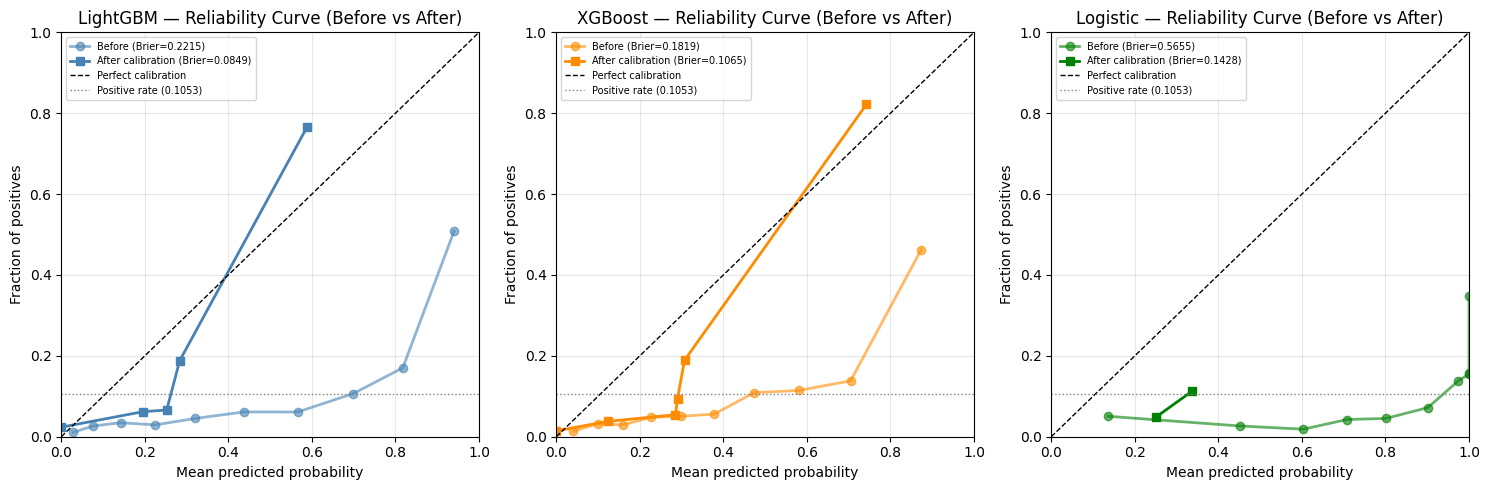

✓ 保存: results_calibration/reliability_curves.png

Step 7: 阈值表格 (LightGBM，校准后)
 threshold  precision  recall     f1  false_alert_rate  total_alerts  alerts_per_day  missed_events
      0.05     0.1569  0.9141 0.2679            0.5784          2307           109.9             34
      0.10     0.1570  0.9116 0.2679            0.5763          2299           109.5             35
      0.15     0.1572  0.9116 0.2682            0.5754          2296           109.3             35
      0.20     0.1578  0.9116 0.2691            0.5727          2287           108.9             35
      0.25     0.1579  0.9091 0.2691            0.5709          2280           108.6             36
      0.30     0.8538  0.2803 0.4221            0.0056           130             6.2            285
      0.35     0.8739  0.2626 0.4039            0.0045           119             5.7            292
      0.40     0.8718  0.2576 0.3977            0.0045           117             5.6            294
      0.45     0.8879 

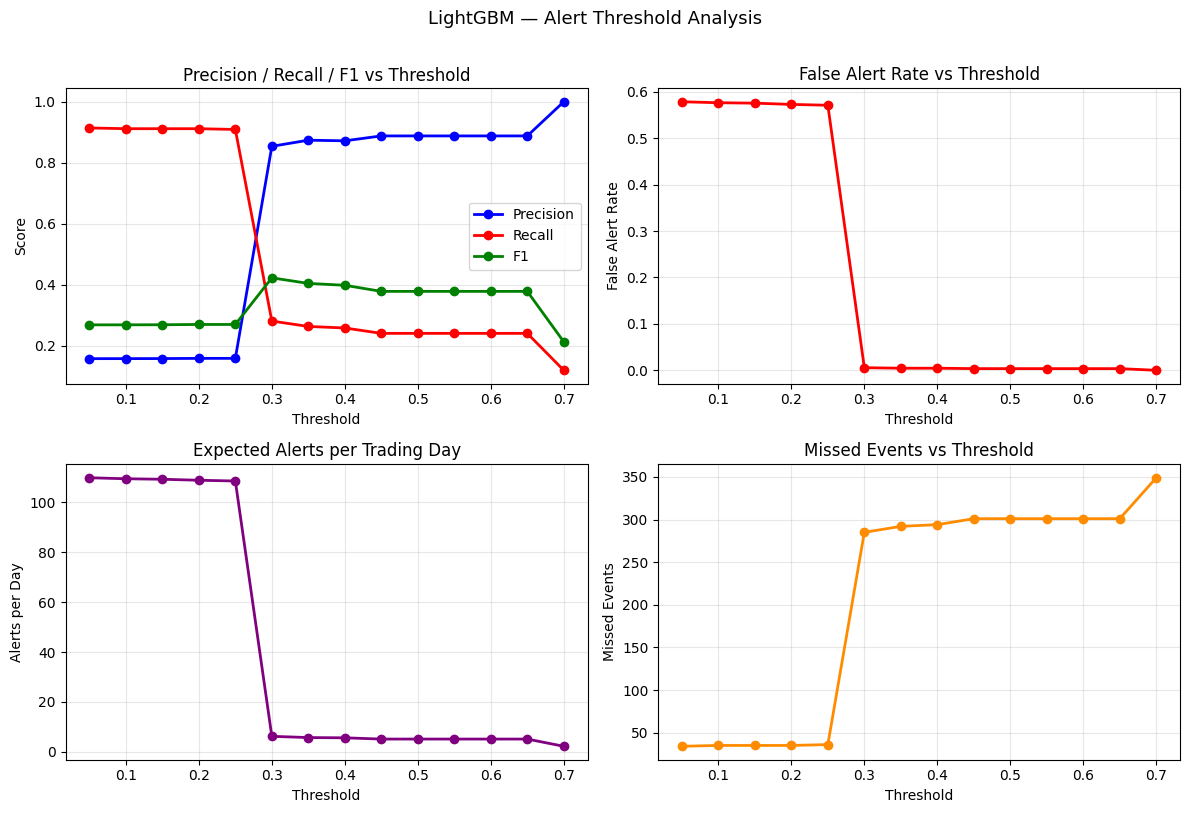

✓ 保存: results_calibration/threshold_analysis.png

=== 汇总 ===
          model  pr_auc  roc_auc  brier_before  brier_skill_before  brier_after_calibration  brier_skill_after
       LightGBM  0.5487   0.8238        0.2215             -1.3497                   0.0849             0.0988
        XGBoost  0.4895   0.7955        0.1819             -0.9300                   0.1065            -0.1300
       Logistic  0.2995   0.7478        0.5655             -4.9996                   0.1428            -0.5152
Random baseline  0.1053   0.5000        0.0942              0.0000                   0.0942             0.0000

✓ 保存: results_calibration/calibration_summary.csv

✓ 所有校准分析完成，文件保存在: results_calibration/


In [2]:
"""
Calibration Analysis
====================
针对LightGBM（主力模型）的校准分析：
1. Brier Score
2. Reliability Curve（校准曲线）
3. 阈值表格：precision/recall/false-alert rate/每日预警次数
4. 对比三个模型的校准质量

输入: data/merged_data_scaled_CLEAN.parquet
      data/feature_groups_CLEAN.json
输出: results_calibration/
"""

import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# ── 配置 ──────────────────────────────────────────────────────────────────────
DATA_FILE   = 'data/merged_data_scaled_CLEAN.parquet'
GROUPS_FILE = 'data/feature_groups_CLEAN.json'
TARGET      = 'EWS_15min'
RANDOM_SEED = 42

TRAIN_END  = '2021-01-25 23:59:59'
VAL_START  = '2021-01-26 00:00:00'
VAL_END    = '2021-01-27 23:59:59'
TEST_START = '2021-01-28 00:00:00'
TEST_END   = '2021-02-28 23:59:59'

LEAKAGE_FEATURES = [
    'is_episode_t', 'is_luld', 'is_anomaly',
    'is_price_spike', 'is_volume_surge',
    'thread_concentration', 'is_official_halt',
]

# 每日交易分钟数（9:30-16:00，5分钟bar）
BARS_PER_DAY = 78

OUT_DIR = 'results_calibration'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'输出目录: {OUT_DIR}/')

# ── 1. 加载数据 ────────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 1: 加载数据')
print('='*65)

df = pd.read_parquet(DATA_FILE)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

with open(GROUPS_FILE, 'r', encoding='utf-8') as f:
    feature_groups = json.load(f)

# halt lag加入market组
halt_lag = [c for c in ['is_official_halt_lag1', 'is_official_halt_lag2']
            if c in df.columns]
if halt_lag:
    feature_groups['market'] = list(feature_groups.get('market', [])) + halt_lag

# full_with_coordination特征
FULL_GROUPS = ['market', 'cascade', 'network', 'temporal', 'text',
               'burstiness', 'user_overlap', 'text_duplication']

all_features = []
for g in FULL_GROUPS:
    all_features.extend(feature_groups.get(g, []))
all_features = [f for f in dict.fromkeys(all_features) if f in df.columns]
all_features = [f for f in all_features if f not in LEAKAGE_FEATURES]

print(f'数据维度: {df.shape}')
print(f'特征数: {len(all_features)}')

# ── 2. 划分数据集 ──────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 2: 划分数据集')
print('='*65)

train_mask = df['timestamp'] <= TRAIN_END
val_mask   = (df['timestamp'] >= VAL_START) & (df['timestamp'] <= VAL_END)
test_mask  = (df['timestamp'] >= TEST_START) & (df['timestamp'] <= TEST_END)

X_train = df.loc[train_mask, all_features].fillna(0)
y_train = df.loc[train_mask, TARGET]
X_val   = df.loc[val_mask,   all_features].fillna(0)
y_val   = df.loc[val_mask,   TARGET]
X_test  = df.loc[test_mask,  all_features].fillna(0)
y_test  = df.loc[test_mask,  TARGET]

spw = (y_train == 0).sum() / y_train.sum()

print(f'训练集: {len(X_train):,} | 正样本: {int(y_train.sum())} ({y_train.mean()*100:.2f}%)')
print(f'验证集: {len(X_val):,}   | 正样本: {int(y_val.sum())} ({y_val.mean()*100:.2f}%)')
print(f'测试集: {len(X_test):,}  | 正样本: {int(y_test.sum())} ({y_test.mean()*100:.2f}%)')
print(f'\n随机基准 PR-AUC: {y_test.mean():.4f}')

# 测试集天数
test_days = df.loc[test_mask, 'timestamp'].dt.date.nunique()
print(f'测试集天数: {test_days}天')

# ── 3. 训练三个模型 ────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 3: 训练模型')
print('='*65)

MODELS = {
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, random_state=RANDOM_SEED,
        n_jobs=-1, verbose=-1
    ),
    'XGBoost': XGBClassifier(
        max_depth=6, learning_rate=0.05, n_estimators=300,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1, scale_pos_weight=spw, random_state=RANDOM_SEED,
        n_jobs=-1, eval_metric='aucpr', verbosity=0
    ),
    'Logistic': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=RANDOM_SEED, n_jobs=-1
    ),
}

probs = {}
for name, model in MODELS.items():
    model.fit(X_train, y_train)
    probs[name] = model.predict_proba(X_test)[:, 1]
    print(f'  ✓ {name} 训练完成 | PR-AUC: {average_precision_score(y_test, probs[name]):.4f}')

# ── 4. Brier Score ─────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 4: Brier Score')
print('='*65)

# 随机基准的Brier Score
baseline_prob = np.full(len(y_test), y_test.mean())
baseline_brier = brier_score_loss(y_test, baseline_prob)
print(f'  随机基准 Brier Score: {baseline_brier:.4f}')

brier_results = {}
for name, y_prob in probs.items():
    bs = brier_score_loss(y_test, y_prob)
    # Brier Skill Score：相对于随机基准的改善程度
    bss = 1 - bs / baseline_brier
    brier_results[name] = {'brier_score': bs, 'brier_skill_score': bss}
    print(f'  {name}: Brier={bs:.4f} | Skill Score={bss:.4f} ({bss*100:+.1f}% vs baseline)')

# ── 5. Isotonic校准 ───────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 5: Isotonic校准')
print('='*65)

from sklearn.calibration import CalibratedClassifierCV

calibrated_probs = {}
calibrated_brier = {}

for name, model in MODELS.items():
    # 用验证集做Isotonic校准
    calibrated = CalibratedClassifierCV(model, cv='prefit', method='isotonic')
    calibrated.fit(X_val, y_val)
    cal_prob = calibrated.predict_proba(X_test)[:, 1]
    calibrated_probs[name] = cal_prob

    bs_before = brier_results[name]['brier_score']
    bs_after  = brier_score_loss(y_test, cal_prob)
    bss_after = 1 - bs_after / baseline_brier
    calibrated_brier[name] = {'brier_score': bs_after, 'brier_skill_score': bss_after}

    print(f'  {name}:')
    print(f'    校准前 Brier: {bs_before:.4f} | Skill: {brier_results[name]["brier_skill_score"]:.4f}')
    print(f'    校准后 Brier: {bs_after:.4f} | Skill: {bss_after:.4f}')
    improvement = (bs_before - bs_after) / bs_before * 100
    print(f'    改善: {improvement:+.1f}%')

# ── 6. Reliability Curve（校准前后对比）───────────────────────────────────────
print('\n' + '='*65)
print('Step 6: Reliability Curve（校准前后对比）')
print('='*65)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'LightGBM': 'steelblue', 'XGBoost': 'darkorange', 'Logistic': 'green'}

for idx, (name, y_prob) in enumerate(probs.items()):
    ax = axes[idx]

    # 校准前曲线
    frac_before, pred_before = calibration_curve(
        y_test, y_prob, n_bins=10, strategy='quantile'
    )
    # 校准后曲线
    frac_after, pred_after = calibration_curve(
        y_test, calibrated_probs[name], n_bins=10, strategy='quantile'
    )

    ax.plot(pred_before, frac_before, 'o-', color=colors[name], lw=2, alpha=0.6,
            label=f'Before (Brier={brier_results[name]["brier_score"]:.4f})')
    ax.plot(pred_after, frac_after, 's-', color=colors[name], lw=2,
            label=f'After calibration (Brier={calibrated_brier[name]["brier_score"]:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    ax.axhline(y=y_test.mean(), color='gray', lw=1, linestyle=':',
               label=f'Positive rate ({y_test.mean():.4f})')

    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'{name} — Reliability Curve (Before vs After)')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/reliability_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ 保存: {OUT_DIR}/reliability_curves.png')

# ── 6. 阈值表格（主力LightGBM）────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 7: 阈值表格 (LightGBM，校准后)')
print('='*65)

y_prob_lgb = calibrated_probs['LightGBM']  # 用校准后的概率
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
              0.55, 0.60, 0.65, 0.70]

threshold_rows = []
for t in thresholds:
    y_pred = (y_prob_lgb >= t).astype(int)
    tp = ((y_pred == 1) & (y_test == 1)).sum()
    fp = ((y_pred == 1) & (y_test == 0)).sum()
    fn = ((y_pred == 0) & (y_test == 1)).sum()
    tn = ((y_pred == 0) & (y_test == 0)).sum()

    prec   = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1     = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0  # false alert rate
    alerts = y_pred.sum()
    alerts_per_day = alerts / test_days

    threshold_rows.append({
        'threshold':        t,
        'precision':        round(prec, 4),
        'recall':           round(rec, 4),
        'f1':               round(f1, 4),
        'false_alert_rate': round(fpr, 4),
        'total_alerts':     int(alerts),
        'alerts_per_day':   round(alerts_per_day, 1),
        'missed_events':    int(fn),
    })

threshold_df = pd.DataFrame(threshold_rows)
print(threshold_df.to_string(index=False))
threshold_df.to_csv(f'{OUT_DIR}/threshold_table_lgb.csv', index=False)
print(f'\n✓ 保存: {OUT_DIR}/threshold_table_lgb.csv')

# ── 7. 阈值图 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(threshold_df['threshold'], threshold_df['precision'],
               'b-o', lw=2, label='Precision')
axes[0,0].plot(threshold_df['threshold'], threshold_df['recall'],
               'r-o', lw=2, label='Recall')
axes[0,0].plot(threshold_df['threshold'], threshold_df['f1'],
               'g-o', lw=2, label='F1')
axes[0,0].set_xlabel('Threshold')
axes[0,0].set_ylabel('Score')
axes[0,0].set_title('Precision / Recall / F1 vs Threshold')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(threshold_df['threshold'], threshold_df['false_alert_rate'],
               'r-o', lw=2)
axes[0,1].set_xlabel('Threshold')
axes[0,1].set_ylabel('False Alert Rate')
axes[0,1].set_title('False Alert Rate vs Threshold')
axes[0,1].grid(alpha=0.3)

axes[1,0].plot(threshold_df['threshold'], threshold_df['alerts_per_day'],
               'purple', marker='o', lw=2)
axes[1,0].set_xlabel('Threshold')
axes[1,0].set_ylabel('Alerts per Day')
axes[1,0].set_title('Expected Alerts per Trading Day')
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(threshold_df['threshold'], threshold_df['missed_events'],
               'darkorange', marker='o', lw=2)
axes[1,1].set_xlabel('Threshold')
axes[1,1].set_ylabel('Missed Events')
axes[1,1].set_title('Missed Events vs Threshold')
axes[1,1].grid(alpha=0.3)

plt.suptitle('LightGBM — Alert Threshold Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ 保存: {OUT_DIR}/threshold_analysis.png')

# ── 8. 汇总Brier表格 ───────────────────────────────────────────────────────────
brier_df = pd.DataFrame([
    {
        'model':                    name,
        'pr_auc':                   round(average_precision_score(y_test, probs[name]), 4),
        'roc_auc':                  round(roc_auc_score(y_test, probs[name]), 4),
        'brier_before':             round(brier_results[name]['brier_score'], 4),
        'brier_skill_before':       round(brier_results[name]['brier_skill_score'], 4),
        'brier_after_calibration':  round(calibrated_brier[name]['brier_score'], 4),
        'brier_skill_after':        round(calibrated_brier[name]['brier_skill_score'], 4),
    }
    for name in MODELS
])
brier_df.loc[len(brier_df)] = {
    'model': 'Random baseline',
    'pr_auc': round(y_test.mean(), 4),
    'roc_auc': 0.5,
    'brier_before': round(baseline_brier, 4),
    'brier_skill_before': 0.0,
    'brier_after_calibration': round(baseline_brier, 4),
    'brier_skill_after': 0.0,
}

print('\n=== 汇总 ===')
print(brier_df.to_string(index=False))
brier_df.to_csv(f'{OUT_DIR}/calibration_summary.csv', index=False)
print(f'\n✓ 保存: {OUT_DIR}/calibration_summary.csv')
print(f'\n✓ 所有校准分析完成，文件保存在: {OUT_DIR}/')